## Présentation du problème

**Objectif**: 

Prédire si une journée est pluvieuse à partir de caractéristiques météorologiques disponibles


**Modèle final retenu** : Gradient Boosting (RandomizedSearchCV affiné).



**Performance** : F1-score de 0.68 sur le test set (jamais utilisé avant

cette évaluation finale), à comparer à un F1 de 0.62 pour un modèle

naïf de référence.

**Limite principale** : la proportion de jours pluvieux diffère entre les

périodes d'entraînement et de test, ce qui reflète la variabilité

saisonnière du climat de Cotonou plutôt qu'un défaut du modèle.

## Table des matières

- [1. Localisation du projet](#1-localisation-du-projet)
- [2. Importation des bibliothèques et des modules du projet](#2-importation-des-bibliothèques-et-des-modules-du-projet)
- [3. Chargement des données brutes](#3-chargement-des-données-brutes)
- [4. Préparation des features](#4-préparation-des-features)
- [5. Vérification de la qualité des données](#5-vérification-de-la-qualité-des-données)
- [6. Analyse exploratoire des données (EDA)](#6-analyse-exploratoire-des-données-eda)
- [7. Séparation des données en 3 ensembles (train / validation / test) & Création de la variable cible](#7-séparation-des-données-en-3-ensembles-train-validation-test-création-de-la-variable-cible)
- [8. Modèle de référence naïf (baseline)](#8-modèle-de-référence-naïf-baseline)
- [9. Modèle 1 - Régression logistique (modèle de référence)](#9-modèle-1---régression-logistique-modèle-de-référence)
- [10. Modèle 2 : Random Forest - modèle initial](#10-modèle-2-random-forest---modèle-initial)
- [11. Modèle 3 : Gradient Boosting - modèle initial](#11-modèle-3-gradient-boosting---modèle-initial)
- [12. Random Forest Classifier -première optimisation](#12-random-forest-classifier--première-optimisation)
- [13. Gradient Boosting Classifier- première optimisation](#13-gradient-boosting-classifier--première-optimisation)
- [14. Tentative d'optimisation : affinage des hyperparamètres](#14-tentative-doptimisation-affinage-des-hyperparamètres)
- [15. GridSearchCV](#15-gridsearchcv)
- [16. Comparaison de tous les F1](#16-comparaison-de-tous-les-f1)
- [17. Comparaison finale des deux modèles candidats](#17-comparaison-finale-des-deux-modèles-candidats)
- [18. Importance des features (Gradient Boosting affiné)](#18-importance-des-features-gradient-boosting-affiné)
- [19. Conclusion et choix du modèle final](#19-conclusion-et-choix-du-modèle-final)
- [20. Évaluation finale sur le test set](#20-évaluation-finale-sur-le-test-set)
- [21. Sauvegarde du modèle final](#21-sauvegarde-du-modèle-final)
- [22. Limites et pistes d'amélioration](#22-limites-et-pistes-damélioration)

## 1. Localisation du projet

On détecte automatiquement la racine du repo (le dossier qui contient `src/`), 
pour que le notebook fonctionne peu importe d'où il est lancé, et pour que les
imports depuis `src` fonctionne.

In [1]:
import sys, os
import pandas as pd

# Trouve automatiquement la racine du repo en remontant
# jusqu'à trouver un dossier contenant 'src'
RACINE_PROJET = os.getcwd()
while not os.path.isdir(os.path.join(RACINE_PROJET, "src")):
    parent = os.path.dirname(RACINE_PROJET)
    if parent == RACINE_PROJET:
        raise RuntimeError("Dossier 'src' introuvable — vérifie que tu lances "
                            "le notebook depuis un dossier à l'intérieur du repo")
    RACINE_PROJET = parent

if RACINE_PROJET not in sys.path:
    sys.path.append(RACINE_PROJET)


print("Racine du projet :", RACINE_PROJET)

Racine du projet : e:\cosit-stage-prediction-meteo


## 2. Importation des bibliothèques et des modules du projet

On importe les fonctions et constantes partagées définies dans `src/` (chargement des données, préparation des features, création de la cible, et les paramètres communs comme la taille du split et le nombre de folds).

In [2]:
#Manipulation des données
import pandas as pd
import numpy as np

#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier


#Optimisation des hyperparamètres
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

#Evaluation
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

#Modules
from src.data_loading import charger_donnees
from src.features import preparer_features, creer_cible_pluie
from src.config import FEATURES_COMMUNES, TAILLE_TEST, RANDOM_STATE

## 3. Chargement des données brutes 

On charge le fichier CSV Open-Meteo (en sautant les lignes de métadonnées en en-tête), et on vérifie que le fichier a bien été trouvé et lu.

In [3]:
CHEMIN_CSV = os.path.join(RACINE_PROJET, "data", "data_OPEN_METEO.csv")
print("CSV trouvé :", os.path.exists(CHEMIN_CSV))

df = charger_donnees(CHEMIN_CSV)
df.head()


CSV trouvé : True


,time,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),relative_humidity_2m_mean (%),surface_pressure_mean (hPa),cloud_cover_mean (%),sunshine_duration (s),mois
0,2015-01-01,2,29.3,24.5,26.9,0.0,0.0,0.0,17.0,34.9,215,79,1010.2,10,41319.21,1
1,2015-01-02,0,29.2,24.6,27.0,0.0,0.0,0.0,15.1,32.0,204,78,1011.0,4,41278.21,1
2,2015-01-03,3,28.9,24.7,26.9,0.0,0.0,0.0,16.7,31.3,174,83,1012.2,39,40985.12,1
3,2015-01-04,3,29.4,23.9,26.5,0.0,0.0,0.0,12.7,24.5,117,73,1012.6,15,41837.27,1
4,2015-01-05,0,29.1,23.0,25.8,0.0,0.0,0.0,12.3,24.1,91,57,1012.2,0,41934.91,1


## 4. Préparation des features 

On renomme les colonnes brutes en noms simples (humidité, pression, vent,...) et on convertit la durée d'ensoleillement de secondes en heures. Cette fonction est commune aux deux modèles du projet.

In [4]:
df = preparer_features(df)
df.head()


,time,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),...,surface_pressure_mean (hPa),cloud_cover_mean (%),sunshine_duration (s),mois,humidite,pression,vent_vitesse,vent_rafales,nuages,sunshine_duration_heures
0,2015-01-01,2,29.3,24.5,26.9,0.0,0.0,0.0,17.0,34.9,...,1010.2,10,41319.21,1,79,1010.2,17.0,34.9,10,11.477558
1,2015-01-02,0,29.2,24.6,27.0,0.0,0.0,0.0,15.1,32.0,...,1011.0,4,41278.21,1,78,1011.0,15.1,32.0,4,11.466169
2,2015-01-03,3,28.9,24.7,26.9,0.0,0.0,0.0,16.7,31.3,...,1012.2,39,40985.12,1,83,1012.2,16.7,31.3,39,11.384756
3,2015-01-04,3,29.4,23.9,26.5,0.0,0.0,0.0,12.7,24.5,...,1012.6,15,41837.27,1,73,1012.6,12.7,24.5,15,11.621464
4,2015-01-05,0,29.1,23.0,25.8,0.0,0.0,0.0,12.3,24.1,...,1012.2,0,41934.91,1,57,1012.2,12.3,24.1,0,11.648586


## 5. Vérification de la qualité des données

Avant de poursuivre, on vérifie l'absence de valeurs manquantes et de valeurs aberrantes dans les features utilisées.

### 5.1. Types des variables

In [5]:
print("=== Types des variables  ===")
print(df.info())

=== Types des variables  ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   time                             3653 non-null   datetime64[ns]
 1   weather_code (wmo code)          3653 non-null   int64         
 2   temperature_2m_max (°C)          3653 non-null   float64       
 3   temperature_2m_min (°C)          3653 non-null   float64       
 4   temperature_2m_mean (°C)         3653 non-null   float64       
 5   precipitation_sum (mm)           3653 non-null   float64       
 6   rain_sum (mm)                    3653 non-null   float64       
 7   precipitation_hours (h)          3653 non-null   float64       
 8   wind_speed_10m_max (km/h)        3653 non-null   float64       
 9   wind_gusts_10m_max (km/h)        3653 non-null   float64       
 10  wind_direction_10m_dominant (°)

### 5.2. Valeurs manquantes

In [6]:
print("Valeurs manquantes par colonne :")
print(df[FEATURES_COMMUNES].isna().sum())

Valeurs manquantes par colonne :
humidite                    0
pression                    0
vent_vitesse                0
vent_rafales                0
nuages                      0
mois                        0
sunshine_duration_heures    0
dtype: int64


### 5.3. Nombre de doublons

In [7]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


### 5.4. Statistiques descriptives

In [8]:
print("\n Statistiques descriptives :")
df[FEATURES_COMMUNES].describe()


 Statistiques descriptives :


,humidite,pression,vent_vitesse,vent_rafales,nuages,mois,sunshine_duration_heures
count,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,82.963865,1010.526088,18.177498,34.407309,67.578976,6.522310,9.714151
std,5.033492,1.739281,3.471260,5.291037,24.984247,3.449345,2.457421
min,40.000000,1005.900000,7.300000,18.000000,0.000000,1.000000,0.000000
25%,82.000000,1009.200000,15.700000,30.600000,51.000000,4.000000,9.372911
50%,84.000000,1010.400000,17.900000,34.200000,72.000000,7.000000,10.509347
75%,86.000000,1011.800000,20.400000,37.800000,89.000000,10.000000,11.112694
max,93.000000,1016.100000,40.200000,66.600000,100.000000,12.000000,12.000000


Aucune valeur manquante, aberrante et aucun doublon détectée. Les données proviennent d'Open-Météo, basées sur des modèles de réanalyse (ERA5), ce qui explique l'absence de trous typiques des relevés de stations physiques.

## 6. Analyse exploratoire des données (EDA)

Avant de passer à la modélisation, on explore la structure des données : 
répartition de la variable cible, distribution des features, corrélations 
entre elles, et relation entre chaque feature et la pluie.

### 6.1. Répartition de la variable cible (pluie)

Proportion de jours pluvieux : 0.508


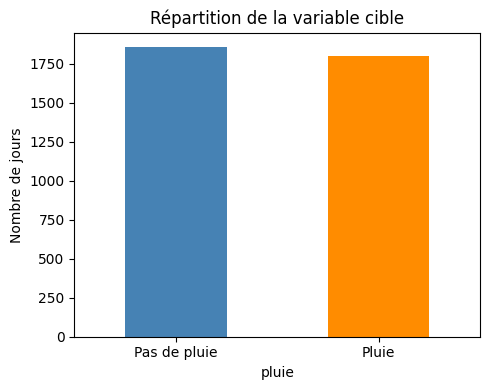

In [9]:
y_complet = creer_cible_pluie(df)

print("Proportion de jours pluvieux :", y_complet.mean().round(3))

plt.figure(figsize=(5, 4))
y_complet.value_counts().plot(kind="bar", color=["steelblue", "darkorange"])
plt.xticks([0, 1], ["Pas de pluie", "Pluie"], rotation=0)
plt.ylabel("Nombre de jours")
plt.title("Répartition de la variable cible")
plt.tight_layout()
plt.show()

### 6.2. Distributions des features

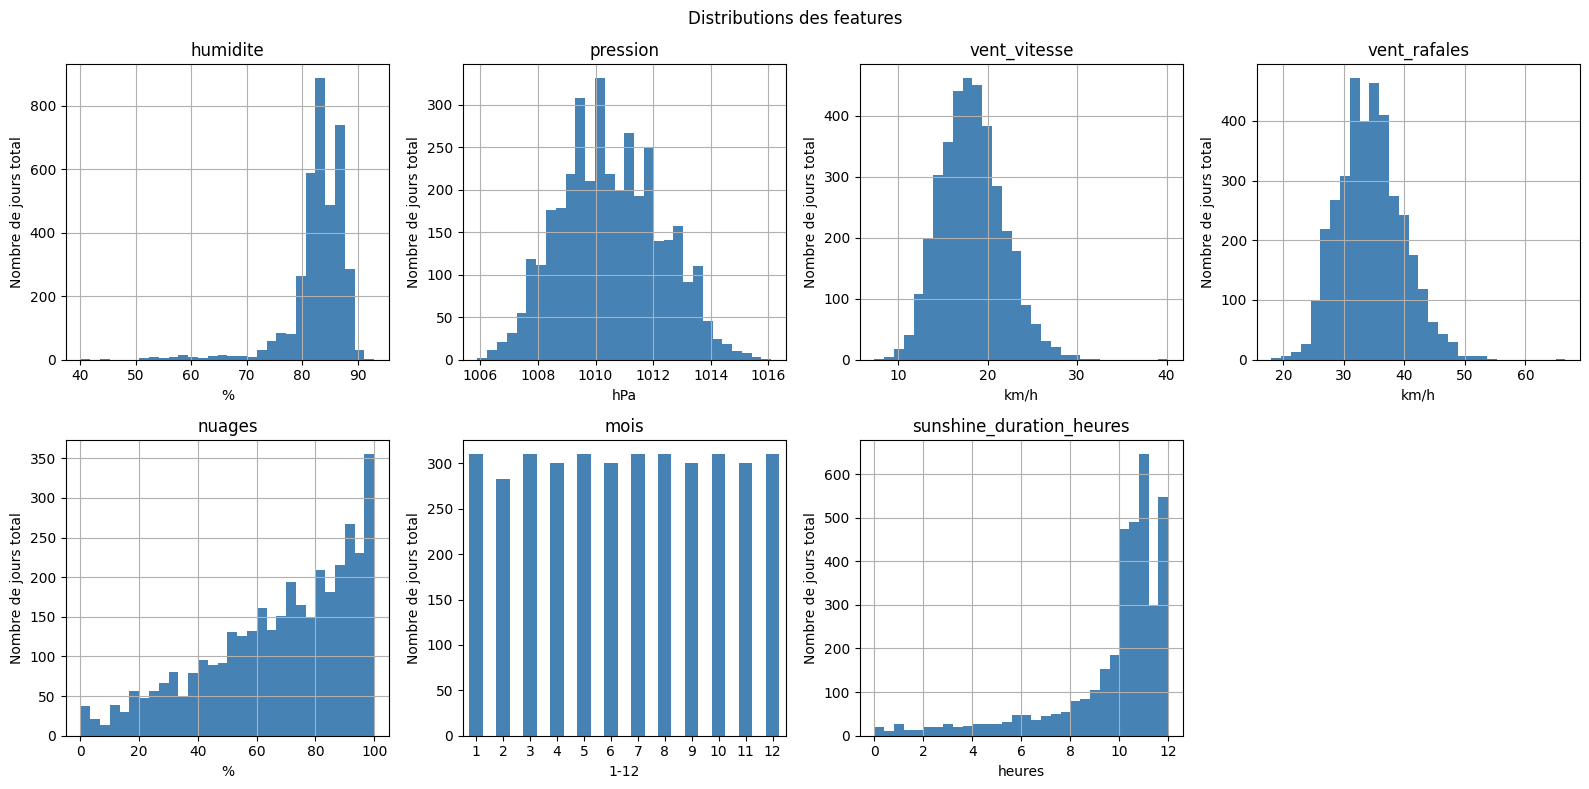

In [10]:
unites = {
    "humidite": "%",
    "pression": "hPa",
    "vent_vitesse": "km/h",
    "vent_rafales": "km/h",
    "nuages": "%",
    "mois": "1-12",
    "sunshine_duration_heures": "heures",
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, FEATURES_COMMUNES):
    if feature == "mois":
        df[feature].value_counts().sort_index().plot(kind="bar", color="steelblue", ax=ax)
        ax.set_xticklabels(range(1, 13), rotation=0)
    else:
        df[feature].hist(bins=30, color="steelblue", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel(unites[feature])
    ax.set_ylabel("Nombre de jours total")

axes[-1].axis("off")
plt.suptitle("Distributions des features")
plt.tight_layout()
plt.show()

### 6.3. Corrélations entre features

On vérifie en particulier si certaines variables sont redondantes 
(fortement corrélées entre elles), comme la vitesse du vent et les rafales.

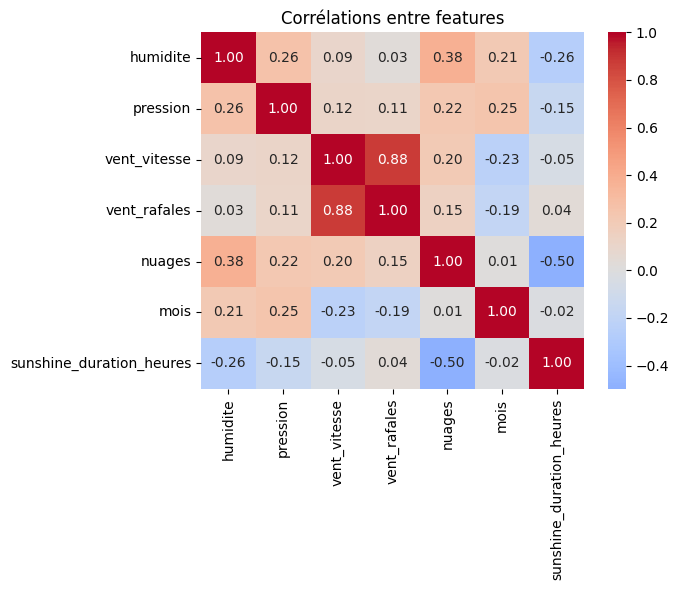

In [11]:
plt.figure(figsize=(7, 6))
sns.heatmap(df[FEATURES_COMMUNES].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Corrélations entre features")
plt.tight_layout()
plt.show()

### 6.4. Relation entre chaque feature et la pluie

C:\Users\DELL LATITUDE 3310\AppData\Local\Temp\ipykernel_9912\1238335914.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="pluie", y=feature, ax=ax, palette=["steelblue", "darkorange"])
C:\Users\DELL LATITUDE 3310\AppData\Local\Temp\ipykernel_9912\1238335914.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Pas de pluie", "Pluie"])
C:\Users\DELL LATITUDE 3310\AppData\Local\Temp\ipykernel_9912\1238335914.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="pluie", y=feature, ax=ax, palette=["steelblue", "darkorange"])
C:\Users\DELL LATITUDE 3310\AppData

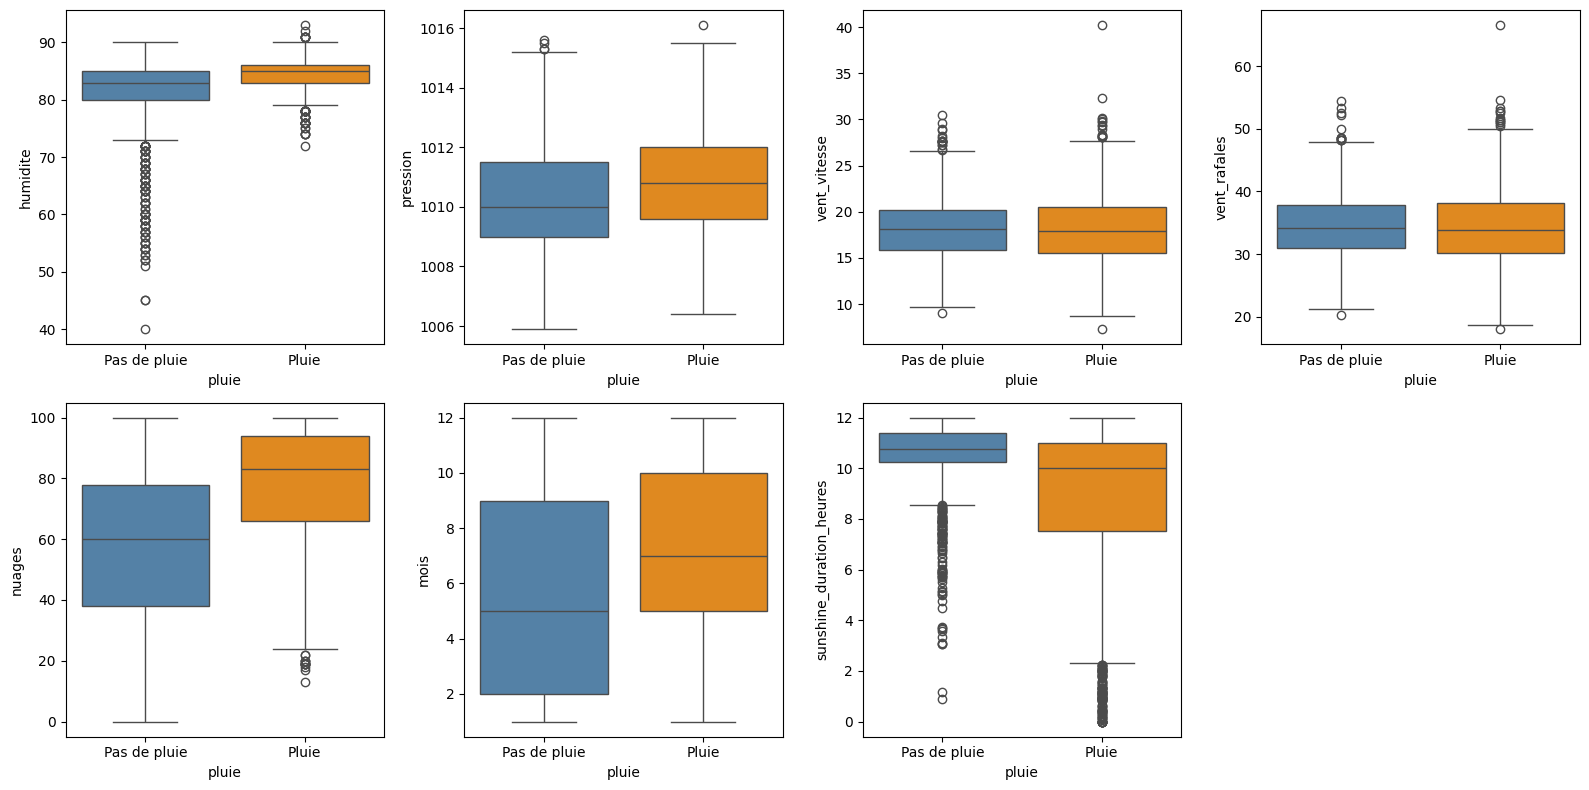

In [12]:
df_eda = df[FEATURES_COMMUNES].copy()
df_eda["pluie"] = y_complet

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, FEATURES_COMMUNES):
    sns.boxplot(data=df_eda, x="pluie", y=feature, ax=ax, palette=["steelblue", "darkorange"])
    ax.set_xticklabels(["Pas de pluie", "Pluie"])

axes[-1].axis("off")  # 7 features pour 8 emplacements, on masque le dernier
plt.tight_layout()
plt.show()

### 6.5. Taux de pluie par mois

On visualise si le taux de pluie suit une logique saisonnière cyclique 
(décembre proche de janvier climatiquement, malgré un écart numérique de 11), 
ce qui justifierait un encodage cyclique du mois plutôt qu'une valeur brute.

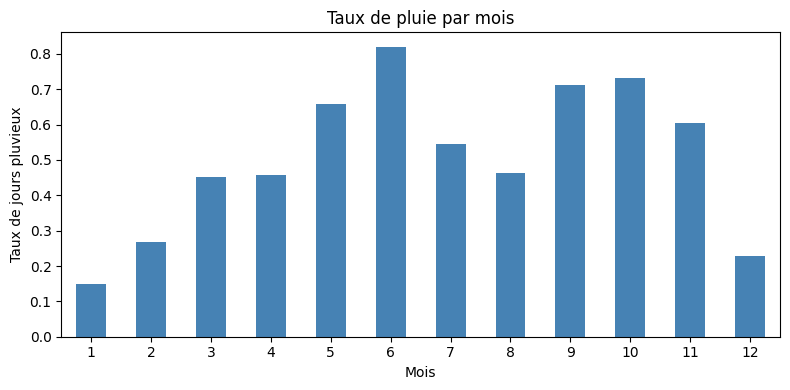

In [13]:
taux_pluie_mois = df_eda.groupby(df["mois"])["pluie"].mean()

plt.figure(figsize=(8, 4))
taux_pluie_mois.plot(kind="bar", color="steelblue")
plt.xlabel("Mois")
plt.ylabel("Taux de jours pluvieux")
plt.title("Taux de pluie par mois")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Séparation des données en 3 ensembles (train / validation / test) & Création de la variable cible

Les données étant temporelles (autocorrélation saisonnière), la séparation 
se fait chronologiquement plutôt qu'aléatoirement : les données les plus 
anciennes servent à l'entraînement, les plus récentes à la validation et 
au test. 

La variable cible (pluie) n'existe pas directement dans le CSV : on la crée ensuite séparément pour chaque ensemble à partir de `precipitation_sum`. Un jour est considéré "pluvieux" (1) si les précipitations dépassent 1mm, sinon "non pluvieux" (0).

- **Train (60%)** : entraînement des modèles
- **Validation (20%)** : comparaison des modèles entre eux et choix du 
  modèle final
- **Test (20%)** : évaluation finale unique, sur le modèle déjà choisi

In [14]:
# Ceci nous confirme que les dates sont alignées chronologiquement dans le dataset
print(df['time'].is_monotonic_increasing)

True


In [15]:
n = len(df)
fin_train = int(n * 0.6)
fin_val = int(n * 0.8)

df_train = df.iloc[:fin_train]
df_val = df.iloc[fin_train:fin_val]
df_test = df.iloc[fin_val:]

# Entraînement
X_train = df_train[FEATURES_COMMUNES]
y_train = creer_cible_pluie(df_train)

#Validation entre les différents modèles
X_val = df_val[FEATURES_COMMUNES]
y_val = creer_cible_pluie(df_val)

# Test pour évaluer le comportement de notre modèle final face à de futurs données
X_test = df_test[FEATURES_COMMUNES]
y_test = creer_cible_pluie(df_test)

print("Train :", X_train.shape, "| Val :", X_val.shape, "| Test :", X_test.shape)
print("Proportion pluie — train :", y_train.mean().round(3),
      "| val :", y_val.mean().round(3),
      "| test :", y_test.mean().round(3))


Train : (2191, 7) | Val : (731, 7) | Test : (731, 7)
Proportion pluie — train : 0.529 | val : 0.503 | test : 0.449


## 8. Modèle de référence naïf (baseline)

Avant de juger si un score de F1 est "bon", on établit un point de 
comparaison minimal : un classifieur qui prédit toujours la classe 
majoritaire, sans aucune logique. Tout modèle entraîné doit faire 
significativement mieux que ce baseline pour être considéré utile.

### 8.1. Entraînement du modèle et affichage des scores (précision, rappel, f1-score)

In [16]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_val)

print("=== Baseline naïf (classe majoritaire) ===")
print(classification_report(y_val, y_pred_baseline))

=== Baseline naïf (classe majoritaire) ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       363
           1       0.50      1.00      0.67       368

    accuracy                           0.50       731
   macro avg       0.25      0.50      0.33       731
weighted avg       0.25      0.50      0.34       731



c:\Users\DELL LATITUDE 3310\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL LATITUDE 3310\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL LATITUDE 3310\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

### 8.2. Ajout des scores (précision, rappel, f1-score) au tableau des résultats

In [17]:
resultats = []

resultats.append({
    "modele": "DummyClassifier",
    "precision" : precision_score(y_val, y_pred_baseline),
    "rappel" : recall_score(y_val, y_pred_baseline),
    "f1" : f1_score(y_val, y_pred_baseline)
})

pd.DataFrame(resultats)

,modele,precision,rappel,f1
0,DummyClassifier,0.50342,1.0,0.6697


## 9. Modèle 1 - Régression logistique (modèle de référence)

On entraîne un modèle simple et interprétable comme point de comparaison pour les modèles suivants (Random Forest, Gradient Boosting). On l'entraîne directement sur le train set, sans recherche d'hyperparamètres complexe, puisque c'est notre référence de base.

### 9.1. Entraînement du modèle

In [18]:
modele_logit = LogisticRegression(random_state= RANDOM_STATE, max_iter= 1000)
modele_logit.fit(X_train, y_train)

y_pred_logit = modele_logit.predict(X_val)

print("=== Régression logistique ===")
print(classification_report(y_val, y_pred_logit))

=== Régression logistique ===
              precision    recall  f1-score   support

           0       0.70      0.63      0.66       363
           1       0.67      0.74      0.70       368

    accuracy                           0.68       731
   macro avg       0.69      0.68      0.68       731
weighted avg       0.69      0.68      0.68       731



### 9.2.  Stockage des métriques pour comparaison finale

On garde les métriques de chaque modèle dans un tableau, pour pouvoir comparer les trois modèles côte à côte à la fin, comme convenu pour le rapport.

In [19]:
resultats.append({
    "modele": "Régression logistique",
    "precision" : precision_score(y_val, y_pred_logit),
    "rappel" : recall_score(y_val, y_pred_logit),
    "f1" : f1_score(y_val, y_pred_logit)
})

pd.DataFrame(resultats)

,modele,precision,rappel,f1
0,DummyClassifier,0.503420,1.00000,0.669700
1,Régression logistique,0.668305,0.73913,0.701935


## 10. Modèle 2 : Random Forest - modèle initial

### 10.1. Entraînement avec les paramètres par défaut

In [20]:
rf_initial = RandomForestClassifier(random_state= RANDOM_STATE)

rf_initial.fit(X_train, y_train)

y_pred_rf_initial = rf_initial.predict(X_val)

### 10.2. Calcul de précsion, rappel, f1-score puis ajout au tableau des résultats

In [21]:
print("===  Random Forest initial ===\n")
print(classification_report(y_val, y_pred_rf_initial))

resultats.append({
    "modele": "Random Forest initial",
    "precision": precision_score(y_val, y_pred_rf_initial),
    "rappel": recall_score(y_val, y_pred_rf_initial),
    "f1": f1_score(y_val, y_pred_rf_initial),
})

pd.DataFrame(resultats)

===  Random Forest initial ===

              precision    recall  f1-score   support

           0       0.71      0.71      0.71       363
           1       0.71      0.72      0.72       368

    accuracy                           0.71       731
   macro avg       0.71      0.71      0.71       731
weighted avg       0.71      0.71      0.71       731



,modele,precision,rappel,f1
0,DummyClassifier,0.503420,1.000000,0.669700
1,Régression logistique,0.668305,0.739130,0.701935
2,Random Forest initial,0.712366,0.720109,0.716216


## 11. Modèle 3 : Gradient Boosting - modèle initial

### 11.1. Entraînement avec les paramètres par défaut

In [22]:
gb_initial = GradientBoostingClassifier(random_state= RANDOM_STATE)

gb_initial.fit(X_train, y_train)

y_pred_gb_initial = gb_initial.predict(X_val)

### 11.2. Calcul de précision, rappel, f1-score puis ajout au tableau des résultats

In [23]:
print("=== Gradient Boosting initial ===\n")
print(classification_report(y_val, y_pred_gb_initial))

resultats.append({
    "modele": "Gradient Boosting initial ",
    "precision": precision_score(y_val, y_pred_gb_initial),
    "rappel": recall_score(y_val, y_pred_gb_initial),
    "f1": f1_score(y_val, y_pred_gb_initial),
})

pd.DataFrame(resultats)

=== Gradient Boosting initial ===

              precision    recall  f1-score   support

           0       0.73      0.67      0.70       363
           1       0.70      0.75      0.73       368

    accuracy                           0.71       731
   macro avg       0.72      0.71      0.71       731
weighted avg       0.72      0.71      0.71       731



,modele,precision,rappel,f1
0,DummyClassifier,0.503420,1.000000,0.669700
1,Régression logistique,0.668305,0.739130,0.701935
2,Random Forest initial,0.712366,0.720109,0.716216
3,Gradient Boosting initial,0.701266,0.752717,0.726081


### 11.3. Comparaison initiale par matrices de confusion 

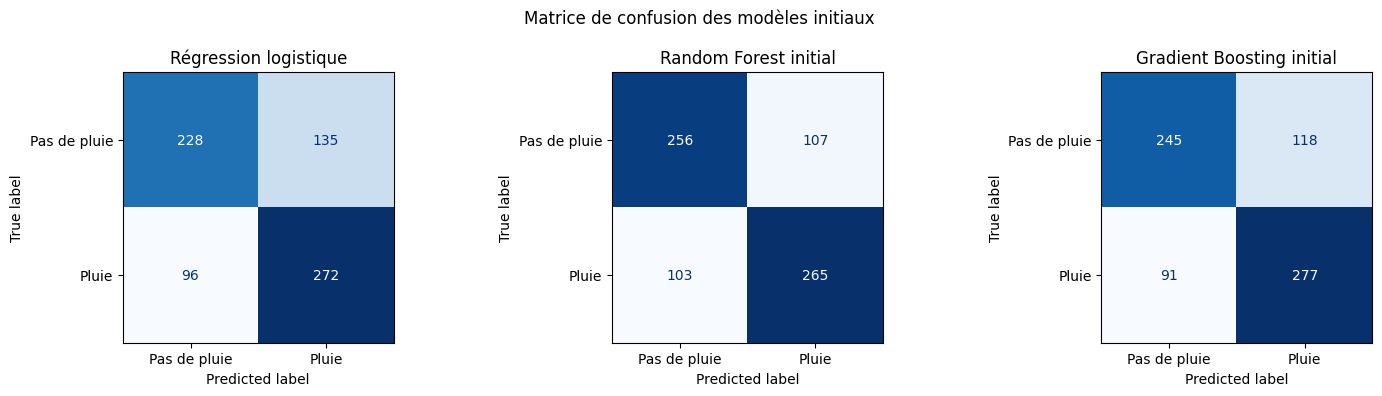

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictions = {
    "Régression logistique": y_pred_logit,
    "Random Forest initial": y_pred_rf_initial,
    "Gradient Boosting initial": y_pred_gb_initial,
}

for ax, (nom_modele, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pas de pluie", "Pluie"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nom_modele)

plt.suptitle("Matrice de confusion des modèles initiaux")
plt.tight_layout()
plt.show()

## 12. Random Forest Classifier -première optimisation

Méthode ensembliste par bagging. On utilise `RandomizedSearchCV` pour explorer un espace d'hyperparamètres et trouver la meilleure combinaison, avec validation croisée à 5 folds sur le train set uniquement.

### 12.1. Recherche du meilleur modèle

In [25]:
grille_rf ={
    "n_estimators": [100, 200, 300, 500],
    "max_depth":   [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    estimator= RandomForestClassifier(random_state= RANDOM_STATE),
    param_distributions= grille_rf,
    n_iter= 30,
    cv= 5,
    scoring= "f1",
    random_state= RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres RF:", rf_search.best_params_)
modele_rf1 = rf_search.best_estimator_

Meilleurs hyperparamètres RF: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}


### 12.2. Evaluation du Random Forest Classifier sur la validation set et ajout des scores (précision, rappel, f1-score) au tableau des résultats

In [26]:
y_pred_rf1 = modele_rf1.predict(X_val)

print("===  Random Forest optimisé===")
print(classification_report(y_val, y_pred_rf1))

resultats.append({
    "modele": "Random Forest optimisé",
    "precision": precision_score(y_val, y_pred_rf1),
    "rappel": recall_score(y_val, y_pred_rf1),
    "f1": f1_score(y_val, y_pred_rf1),
})

pd.DataFrame(resultats)

===  Random Forest optimisé===
              precision    recall  f1-score   support

           0       0.72      0.69      0.70       363
           1       0.71      0.74      0.72       368

    accuracy                           0.71       731
   macro avg       0.71      0.71      0.71       731
weighted avg       0.71      0.71      0.71       731



,modele,precision,rappel,f1
0,DummyClassifier,0.503420,1.000000,0.669700
1,Régression logistique,0.668305,0.739130,0.701935
2,Random Forest initial,0.712366,0.720109,0.716216
3,Gradient Boosting initial,0.701266,0.752717,0.726081
4,Random Forest optimisé,0.705426,0.741848,0.723179


## 13. Gradient Boosting Classifier- première optimisation

Méthode ensembliste par boosting. Comme pour le Random Forest, on utilise 
`RandomizedSearchCV` avec validation croisée à 5 folds pour trouver les 
meilleurs hyperparamètres sur le train set.

### 13.1. Recherche du meilleur modèle

In [27]:
grille_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 0.9, 1.0],
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=grille_gb,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gb_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres GB :", gb_search.best_params_)
modele_gb1 = gb_search.best_estimator_

Meilleurs hyperparamètres GB : {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.05}


### 13.2. Évaluation du Gradient Boosting sur la validation set et ajout des scores (précision, rappel, f1-score) au tableau des résultats

In [28]:
y_pred_gb1 = modele_gb1.predict(X_val)

print("=== Gradient Boosting optimisé ===")
print(classification_report(y_val, y_pred_gb1))

resultats.append({
    "modele": "Gradient Boosting optimisé",
    "precision": precision_score(y_val, y_pred_gb1),
    "rappel": recall_score(y_val, y_pred_gb1),
    "f1": f1_score(y_val, y_pred_gb1),
})

pd.DataFrame(resultats)

=== Gradient Boosting optimisé ===
              precision    recall  f1-score   support

           0       0.75      0.67      0.71       363
           1       0.71      0.79      0.74       368

    accuracy                           0.73       731
   macro avg       0.73      0.73      0.73       731
weighted avg       0.73      0.73      0.73       731



,modele,precision,rappel,f1
0,DummyClassifier,0.503420,1.000000,0.669700
1,Régression logistique,0.668305,0.739130,0.701935
2,Random Forest initial,0.712366,0.720109,0.716216
3,Gradient Boosting initial,0.701266,0.752717,0.726081
4,Random Forest optimisé,0.705426,0.741848,0.723179
5,Gradient Boosting optimisé,0.706601,0.785326,0.743887


### 13.3. Matrices de confusion — comparaison des 3 modèles

On visualise, pour chaque modèle, la répartition entre vrais positifs, 
vrais négatifs, faux positifs et faux négatifs, afin de mieux comprendre 
le type d'erreur commis par chacun.

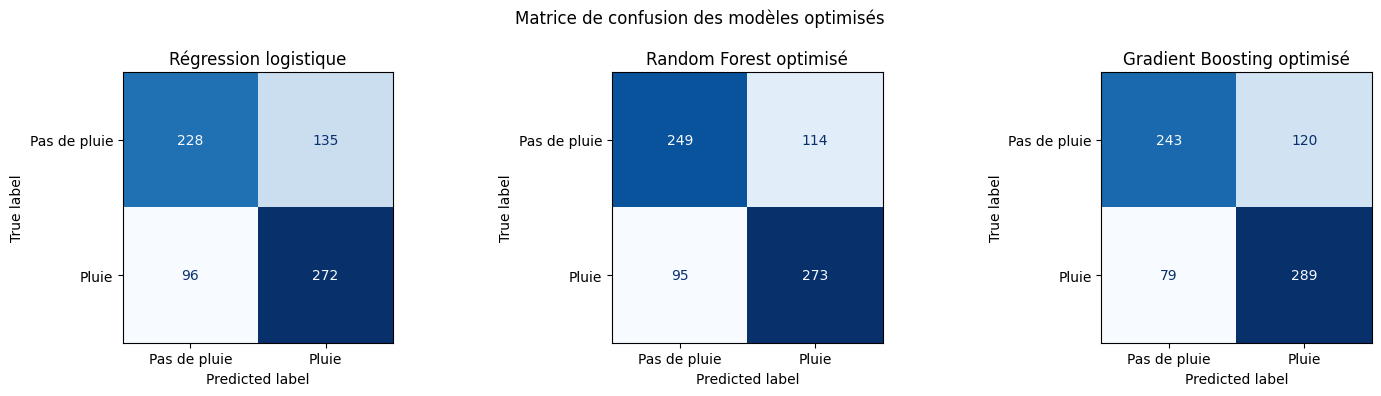

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictions = {
    "Régression logistique": y_pred_logit,
    "Random Forest optimisé": y_pred_rf1,
    "Gradient Boosting optimisé": y_pred_gb1,
}

for ax, (nom_modele, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pas de pluie", "Pluie"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nom_modele)

plt.suptitle("Matrice de confusion des modèles optimisés")
plt.tight_layout()
plt.show()

## 14. Tentative d'optimisation : affinage des hyperparamètres

Après avoir comparé les 3 modèles sur leurs paramètres initiaux, on tente d'améliorer encore les deux modèles ensemblistes (RandomForest et Gradient Boosting) en resserrant la recherche d'hyperparamaètres autour des meilleures valeures déjà trouvées.

### 14.1. Affinement de Random Forest

Meilleurs hyperparamètres RF optimisé : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}

In [30]:
grille_rf_affinee = {
    "n_estimators": [150, 200, 250, 300],
    "max_depth": [None, 20, 25, 30],
    "min_samples_split": [2, 3, 4],
    "min_samples_leaf": [2, 3, 4, 5],
    "max_features": ["sqrt", 0.3, 0.5],
}

rf_search2 = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=grille_rf_affinee,
    n_iter=40,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search2.fit(X_train, y_train)
print("Nouveaux meilleurs hyperparamètres RF :", rf_search2.best_params_)
modele_rf2 = rf_search2.best_estimator_

Nouveaux meilleurs hyperparamètres RF : {'n_estimators': 150, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.3, 'max_depth': 25}


### 14.2. Affinement du Gradient Boosting

Meilleurs hyperparamètres GB optimisé : {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.05}

In [31]:
grille_gb_affinee = {
    "n_estimators": [80, 100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [5, 10, 15],
    "min_samples_leaf": [2, 4, 6],
    "subsample": [0.8, 0.85, 0.9, 0.95],
}

gb_search2 = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=grille_gb_affinee,
    n_iter=40,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
gb_search2.fit(X_train, y_train)
print("Nouveaux meilleurs hyperparamètres GB :", gb_search2.best_params_)
modele_gb2 = gb_search2.best_estimator_

Nouveaux meilleurs hyperparamètres GB : {'subsample': 0.95, 'n_estimators': 80, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': 0.07}


### 14.3. Affichage des scores pour les deux modèles

In [32]:
y_pred_rf2 = modele_rf2.predict(X_val)
y_pred_gb2 = modele_gb2.predict(X_val)

print("=== RF affiné ===\n")
print(classification_report(y_val, y_pred_rf2))

print("\n=== GB affiné ===")
print(classification_report(y_val, y_pred_gb2))

=== RF affiné ===

              precision    recall  f1-score   support

           0       0.73      0.71      0.72       363
           1       0.72      0.74      0.73       368

    accuracy                           0.72       731
   macro avg       0.72      0.72      0.72       731
weighted avg       0.72      0.72      0.72       731


=== GB affiné ===
              precision    recall  f1-score   support

           0       0.76      0.67      0.71       363
           1       0.71      0.80      0.75       368

    accuracy                           0.73       731
   macro avg       0.74      0.73      0.73       731
weighted avg       0.74      0.73      0.73       731



### 14.4. Ajout des scores (précision, rappel, f1-score) au tableau des résultats pour les deux modèles

In [33]:
resultats.append({
    "modele": "RF affiné(RandomizedSearchCV)",
    "precision": precision_score(y_val, y_pred_rf2),
    "rappel": recall_score(y_val, y_pred_rf2),
    "f1": f1_score(y_val, y_pred_rf2),
})

resultats.append({
    "modele": "GB affiné (RandomizedSearchCV)",
    "precision": precision_score(y_val, y_pred_gb2),
    "rappel": recall_score(y_val, y_pred_gb2),
    "f1": f1_score(y_val, y_pred_gb2),
})


pd.DataFrame(resultats)

,modele,precision,rappel,f1
0,DummyClassifier,0.503420,1.000000,0.669700
1,Régression logistique,0.668305,0.739130,0.701935
2,Random Forest initial,0.712366,0.720109,0.716216
3,Gradient Boosting initial,0.701266,0.752717,0.726081
4,Random Forest optimisé,0.705426,0.741848,0.723179
5,Gradient Boosting optimisé,0.706601,0.785326,0.743887
6,RF affiné(RandomizedSearchCV),0.716931,0.736413,0.726542
7,GB affiné (RandomizedSearchCV),0.707729,0.796196,0.749361


### 14.5. Comparaison RF et GB affinés

Visualisation des scores F1 avant/après l'affinage des hyperparamètres, 
pour le Random Forest et le Gradient Boosting.

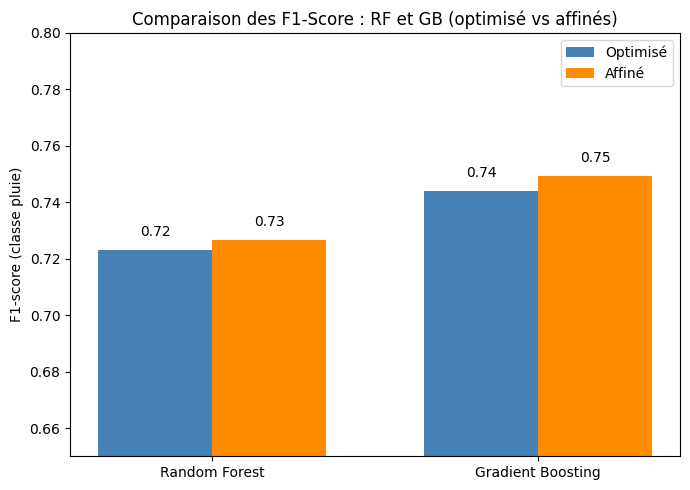

In [34]:
comparaison_affinage = pd.DataFrame({
    "modele": ["Random Forest", "Random Forest", "Gradient Boosting", "Gradient Boosting"],
    "version": ["Original", "Affiné", "Original", "Affiné"],
    "f1": [
        f1_score(y_val, y_pred_rf1),
        f1_score(y_val, y_pred_rf2),
        f1_score(y_val, y_pred_gb1),
        f1_score(y_val, y_pred_gb2),
    ],
})

fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(2)  # 2 modèles
largeur = 0.35

f1_original = comparaison_affinage[comparaison_affinage["version"] == "Original"]["f1"].values
f1_affine = comparaison_affinage[comparaison_affinage["version"] == "Affiné"]["f1"].values

ax.bar(x - largeur/2, f1_original, largeur, label="Optimisé", color="steelblue")
ax.bar(x + largeur/2, f1_affine, largeur, label="Affiné", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(["Random Forest", "Gradient Boosting"])
ax.set_ylabel("F1-score (classe pluie)")
ax.set_ylim(0.65, 0.80)
ax.set_title("Comparaison des F1-Score : RF et GB (optimisé vs affinés)")
ax.legend()

for i, (orig, aff) in enumerate(zip(f1_original, f1_affine)):
    ax.text(i - largeur/2, orig + 0.005, f"{orig:.2f}", ha="center")
    ax.text(i + largeur/2, aff + 0.005, f"{aff:.2f}", ha="center")

plt.tight_layout()
plt.show()

### 14.6. Matrice de confusion des modèles affinés

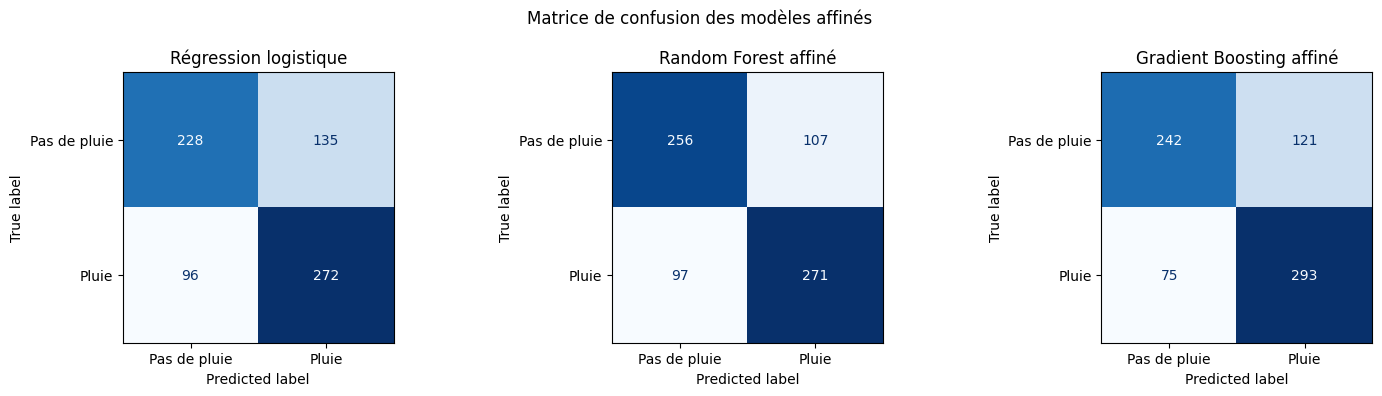

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictions = {
    "Régression logistique": y_pred_logit,
    "Random Forest affiné": y_pred_rf2,
    "Gradient Boosting affiné": y_pred_gb2,
}

for ax, (nom_modele, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pas de pluie", "Pluie"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nom_modele)

plt.suptitle("Matrice de confusion des modèles affinés")
plt.tight_layout()
plt.show()

## 15. GridSearchCV

### 15.1. GridSearchCV - Random Forest

#### 15.1.1. Recherche du meilleur modèle

In [36]:
# Grille ciblée autour des meilleurs hyperparamètres
grille_rf_grid = {
    "n_estimators": [149, 151],
    "max_depth": [24, 26],
    "min_samples_split": [3, 4],
    "min_samples_leaf": [2,3],
    "max_features": [0.29, 0.31]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=grille_rf_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres RF (GridSearch) :", rf_grid.best_params_)
modele_rf_grid = rf_grid.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Meilleurs hyperparamètres RF (GridSearch) : {'max_depth': 26, 'max_features': 0.29, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 149}


### 15.2. GridSearchCV - Gradient Boosting

#### 15.2.1. Recherche du meilleur modèle

In [37]:
# Grille ciblée autour des meilleurs hyperparamètres
grille_gb_grid = {
    "n_estimators": [79, 81],
    "learning_rate": [0.065, 0.075],
    "max_depth": [2, 3],
    "min_samples_split": [9, 10],
    "min_samples_leaf": [3, 4],
    "subsample": [0.94, 0.96]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=grille_gb_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres GB (GridSearch) :", gb_grid.best_params_)
modele_gb_grid = gb_grid.best_estimator_

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Meilleurs hyperparamètres GB (GridSearch) : {'learning_rate': 0.075, 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 79, 'subsample': 0.96}


### 15.3. Ajout des scores (précision, rappel, f1-score) au tableau des résultats pour les deux modèles

In [38]:
y_pred_rf_grid = modele_rf_grid.predict(X_val)
y_pred_gb_grid = modele_gb_grid.predict(X_val)

resultats.append({
        "modele": "Random Forest (GridSearch)",
        "precision": precision_score(y_val, y_pred_rf_grid),
        "rappel": recall_score(y_val, y_pred_rf_grid),
        "f1": f1_score(y_val, y_pred_rf_grid)
    })
resultats.append({
        "modele": "Gradient Boosting (GridSearch)",
        "precision": precision_score(y_val, y_pred_gb_grid),
        "rappel": recall_score(y_val, y_pred_gb_grid),
        "f1": f1_score(y_val, y_pred_gb_grid)
    })


pd.DataFrame(resultats)

resultats = pd.DataFrame(resultats)

### 15.4. Comparaison finale des matrices GridSearchCV

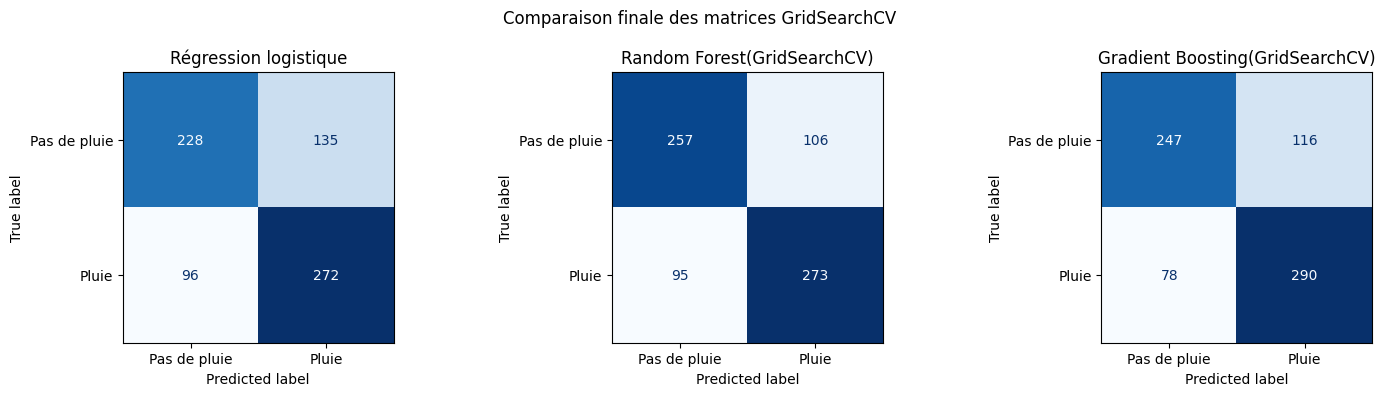

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictions = {
    "Régression logistique": y_pred_logit,
    "Random Forest(GridSearchCV)": y_pred_rf_grid,
    "Gradient Boosting(GridSearchCV)": y_pred_gb_grid,
}

for ax, (nom_modele, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pas de pluie", "Pluie"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nom_modele)

plt.suptitle("Comparaison finale des matrices GridSearchCV")
plt.tight_layout()
plt.show()

## 16. Comparaison de tous les F1

C:\Users\DELL LATITUDE 3310\AppData\Local\Temp\ipykernel_9912\3057643428.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_scores, x="F1-Score", y="Modèle", palette="Blues_r")


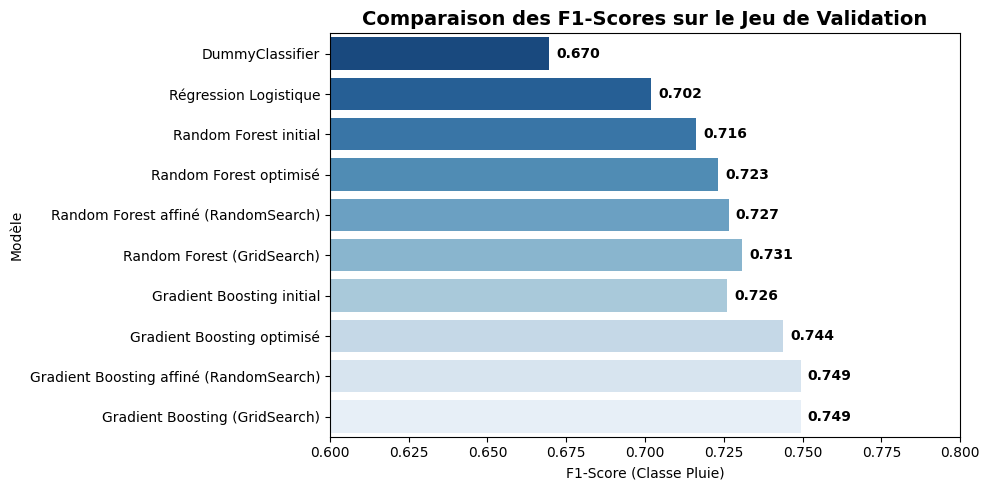

In [40]:
# 1. Calcul des F1-scores sur le jeu de validation
scores = {
    "DummyClassifier" : f1_score(y_val, y_pred_baseline),
    "Régression Logistique": f1_score(y_val, y_pred_logit),
    "Random Forest initial": f1_score(y_val, y_pred_rf_initial),
    "Random Forest optimisé": f1_score(y_val, y_pred_rf1),
     "Random Forest affiné (RandomSearch)": f1_score(y_val, y_pred_rf2),
    "Random Forest (GridSearch)": f1_score(y_val, modele_rf_grid.predict(X_val)),
    "Gradient Boosting initial": f1_score(y_val, y_pred_gb_initial),
    "Gradient Boosting optimisé": f1_score(y_val, y_pred_gb1),
    "Gradient Boosting affiné (RandomSearch)": f1_score(y_val, y_pred_gb2),
    "Gradient Boosting (GridSearch)": f1_score(y_val, modele_gb_grid.predict(X_val)),
}

df_scores = pd.DataFrame(list(scores.items()), columns=["Modèle", "F1-Score"])

# 2. Tracé du graphique
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_scores, x="F1-Score", y="Modèle", palette="Blues_r")

plt.title("Comparaison des F1-Scores sur le Jeu de Validation", fontsize=14, fontweight="bold")
plt.xlabel("F1-Score (Classe Pluie)")
plt.xlim(0.6, 0.8)  # Ajuste l'échelle selon tes résultats

# Affichage des valeurs exactes sur les barres
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.3f}", 
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

D'après le graphique précédent comparant tous les f1-score, on remarque le Gradient Boosting affiné (RandomSearch) et le Gradient Boosting (GridSearch) ont les scores de F1 les plus élevés(0.749 chacun).
On les compare donc suivant d'autres critères pour un choix final.

## 17. Comparaison finale des deux modèles candidats

Les deux modèles candidats présentent des performances globales proches.
Leurs matrices de confusion sont comparées afin d'analyser plus précisément la répartition des erreurs, notamment les faux négatifs.

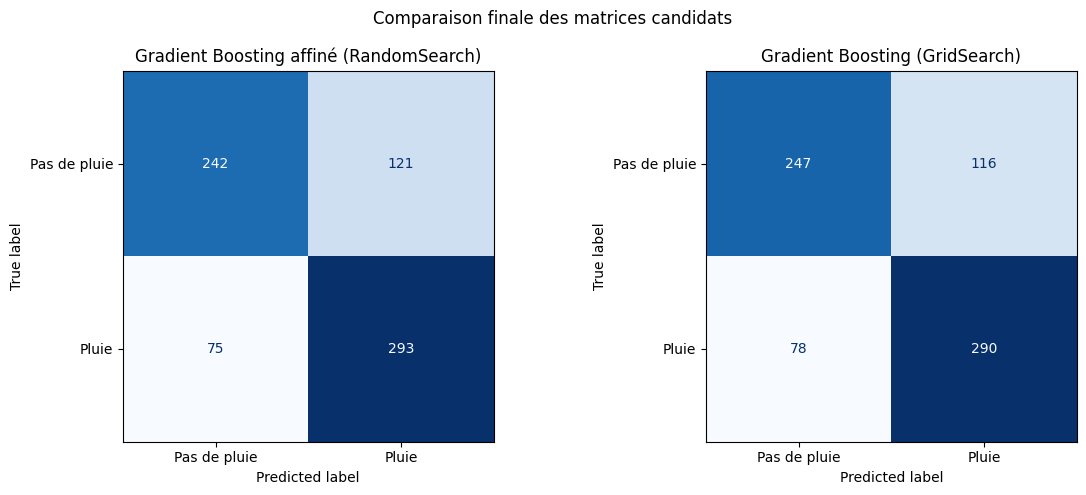

,modele,precision,rappel,f1
0,GB affiné (RandomizedSearchCV),0.707729,0.796196,0.749361
1,Gradient Boosting (GridSearch),0.714286,0.788043,0.749354


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_affine = confusion_matrix(y_val, y_pred_gb2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_affine, display_labels=["Pas de pluie", "Pluie"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Gradient Boosting affiné (RandomSearch)")

cm_grid = confusion_matrix(y_val, y_pred_gb_grid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_grid, display_labels=["Pas de pluie", "Pluie"])
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Gradient Boosting (GridSearch)")
plt.suptitle("Comparaison finale des matrices candidats")
plt.tight_layout()
plt.show()

comparaison_finale = resultats.loc[7:9:2, :]
comparaison_finale = comparaison_finale.reset_index(drop=True)

comparaison_finale

L'intérêt de notre étude est relativement lié à la prédiction de la pluie et manquer un jour de pluie peut être plus crucial que de prédire de la pluie à tort. La matrice de confusion des deux modèles candidats nous montre que le modèle affiné avec RandomizeSearchCV quoi que donnant 5jours de fausse alerte(prédiction de la pluie à tort) que celui sublimé avec GridSearchCV, prédit 3jours de pluie de plus que ce dernier et en manque trois de moins. Ce qui ferait pencher le choix de notre modèle vers celui affiné par le modèle affiné.  

## 18. Importance des features (Gradient Boosting affiné)

On visualise quelles variables météo influencent le plus les prédictions 
du modèle retenu, pour mieux interpréter son fonctionnement.

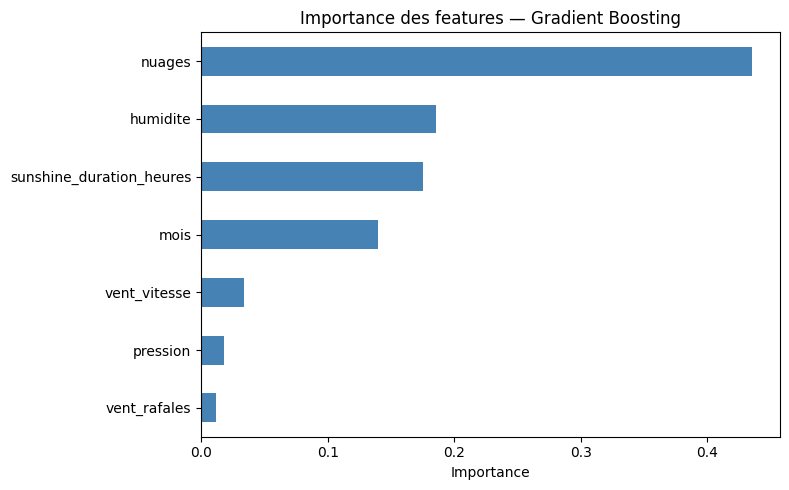

nuages                      0.435535
humidite                    0.185630
sunshine_duration_heures    0.175405
mois                        0.139977
vent_vitesse                0.033982
pression                    0.017885
vent_rafales                0.011587
dtype: float64

In [42]:
modele_final_pluie = gb_search2.best_estimator_
importances = pd.Series(modele_final_pluie.feature_importances_, index=FEATURES_COMMUNES)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Importance des features — Gradient Boosting")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 19. Conclusion et choix du modèle final

En comparant les modèles sur les métriques (precision, rappel, F1) et les 
matrices de confusion, le **Gradient Boosting affiné (RandomizedSearchCV)** 
est retenu comme modèle final, plutôt que sa version GridSearchCV :

- Les deux versions (affinée et GridSearch) atteignent un F1 quasi identique, 
  mais la version GridSearch produit davantage de faux négatifs (jours de 
  pluie ratés) et une precision/rappel légèrement inférieurs — la version 
  affinée prédit davantage de jours de pluie, ce qui réduit ce type d'erreur 
  plus coûteux dans un contexte météo
- L'encodage cyclique du mois (sin/cos) a été testé, mais a fait baisser le 
  F1 du RandomizedSearchCV d'environ 0.003 — la variable `mois` brute est 
  donc conservée, un choix appuyé par l'expérimentation et non par simple 
  souci de simplicité du pipeline

Les variables les plus déterminantes pour les prédictions du modèle final 
sont l'humidité, la couverture nuageuse la durée d'ensoleillement et  — 
cohérent avec la météorologie physique du phénomène pluvieux.


Ce modèle sera sauvegardé et utilisé dans l'application Streamlit finale.

## 20. Évaluation finale sur le test set

Le test set n'a jamais été utilisé jusqu'ici — ni pour l'entraînement, ni 
pour la comparaison des modèles, ni pour le choix des hyperparamètres. On 
l'utilise maintenant une seule fois, sur le modèle final déjà choisi, pour 
obtenir une estimation honnête de sa performance sur des données 
réellement inédites.

### 20.1. Scores, matrice de confusion sur le test set

=== Gradient Boosting affiné — Évaluation finale sur le test set ===
              precision    recall  f1-score   support

           0       0.73      0.79      0.76       403
           1       0.71      0.65      0.68       328

    accuracy                           0.72       731
   macro avg       0.72      0.72      0.72       731
weighted avg       0.72      0.72      0.72       731



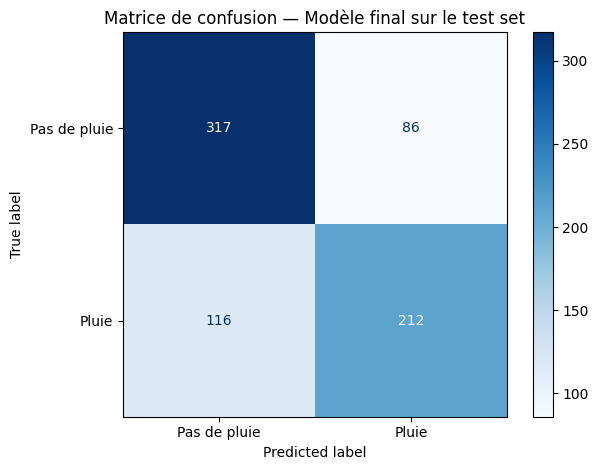

In [43]:
y_pred_test_final = modele_final_pluie.predict(X_test)

print("=== Gradient Boosting affiné — Évaluation finale sur le test set ===")
print(classification_report(y_test, y_pred_test_final))

cm_final = confusion_matrix(y_test, y_pred_test_final)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Pas de pluie", "Pluie"])
disp_final.plot(cmap="Blues")
plt.title("Matrice de confusion — Modèle final sur le test set")
plt.tight_layout()
plt.show()

### 20.2. Evaluation d'un DummyClassifier naïf sur le modèle sur le set test 

In [44]:
y_pred_baseline_test = baseline.predict(X_test)

print("=== Baseline naïf sur le TEST set ===")
print(classification_report(y_test, y_pred_baseline_test))

=== Baseline naïf sur le TEST set ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       403
           1       0.45      1.00      0.62       328

    accuracy                           0.45       731
   macro avg       0.22      0.50      0.31       731
weighted avg       0.20      0.45      0.28       731



c:\Users\DELL LATITUDE 3310\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL LATITUDE 3310\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL LATITUDE 3310\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

### 20.3. Exemple de prédiction



Illustration de l'usage réel du modèle : à partir de conditions météo

données, le modèle retourne une probabilité de pluie.


In [45]:
exemple = pd.DataFrame([{

"humidite": 85,

"pression": 1010,

"vent_vitesse": 15,

"vent_rafales": 30,

"nuages": 70,

"mois": 7,

"sunshine_duration_heures": 5,

}])[FEATURES_COMMUNES]



proba_pluie = modele_final_pluie.predict_proba(exemple)[0][1]

print(f"Conditions données → probabilité de pluie estimée : {proba_pluie:.1%}")

Conditions données → probabilité de pluie estimée : 78.6%


### 20.4. Validation croisée du modèle final



Pour une estimation plus robuste que le score de validation unique, on

calcule le F1-score du modèle final sur 5 folds de validation croisée

(train set uniquement).

In [46]:
scores_cv_final = cross_val_score(modele_final_pluie, X_train, y_train, cv=5, scoring="f1")

print(f"F1 (validation croisée, 5-fold) : {scores_cv_final.mean():.3f} ± {scores_cv_final.std():.3f}")

F1 (validation croisée, 5-fold) : 0.749 ± 0.019


## 21. Sauvegarde du modèle final



Le modèle retenu est sauvegardé au format `.pkl`, pour être chargé par

l'application Streamlit (`app.py`) réalisée par Déo Gracias.

## 22. Limites et pistes d'amélioration



- **Validation croisée non temporelle** : le `cv=5` utilisé dans les

recherches d'hyperparamètres ne respecte pas l'ordre chronologique à

l'intérieur du train set (`TimeSeriesSplit` n'a pas été implémenté,

faute de temps) — une piste pour fiabiliser davantage la sélection

d'hyperparamètres.

- **Déséquilibre variable entre périodes** : la proportion de jours

pluvieux diffère entre le train et le test, reflet de la variabilité

saisonnière du climat de Cotonou (deux saisons des pluies), plutôt

qu'un artefact du split.

- **Encodage cyclique du mois testé et écarté** : une transformation

sin/cos du mois a été testée, mais a légèrement dégradé le F1

(~0.003) — la variable brute est donc conservée.

- **Portée géographique limitée** : le modèle est entraîné uniquement

sur des données de Cotonou ; sa généralisation à d'autres zones

climatiques n'est pas garantie.